# Make Segments

## Clean dataset

In [ ]:
from fn.pipeline import preprocess_and_save_dataset
preprocess_and_save_dataset(
    r"data\machine_translation_docs_info.json",
    r"data\translation_dataset.pkl"
)
preprocess_and_save_dataset(
    r"data\machine_learning_docs_info.json",
    r"data\learning_dataset.pkl"
)

Preprocessing dataset...
Saved processed dataset to data\translation_dataset.pkl
Preprocessing dataset...
Saved processed dataset to data\learning_dataset.pkl



=== TRANSLATION ===


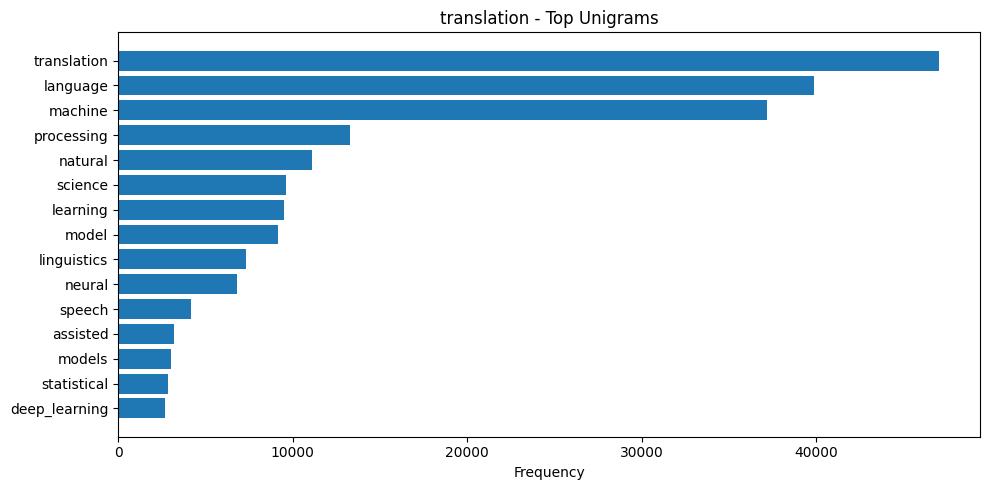

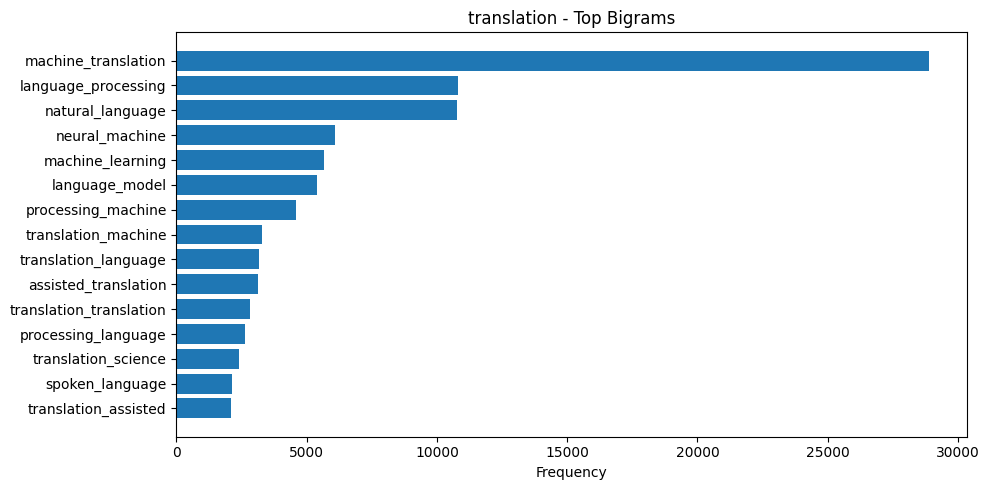

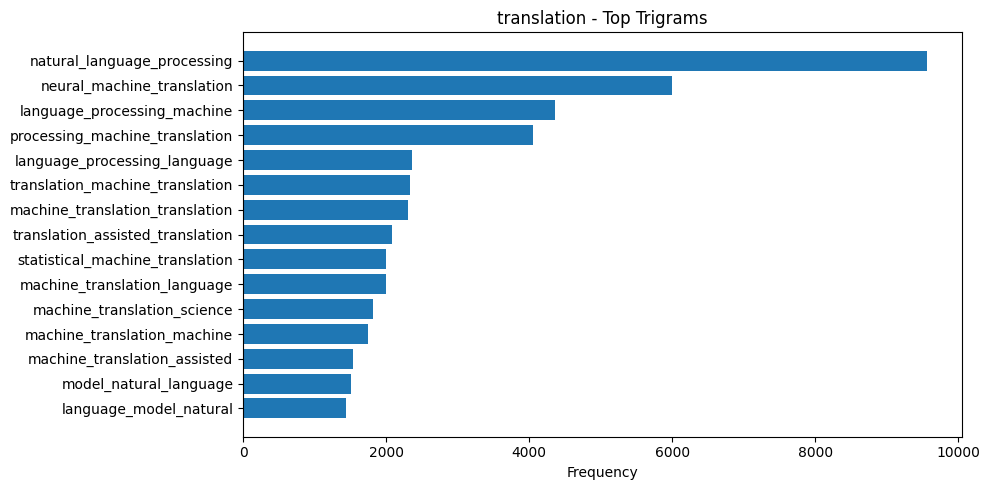

In [1]:
import pickle
from collections import Counter
import matplotlib.pyplot as plt


def extract_ngrams(tokens_list):
    unigram = Counter()
    bigram = Counter()
    trigram = Counter()

    for tokens in tokens_list:
        unigram.update(tokens)

        bigram.update([
            "_".join(tokens[i:i+2])
            for i in range(len(tokens)-1)
        ])

        trigram.update([
            "_".join(tokens[i:i+3])
            for i in range(len(tokens)-2)
        ])

    return unigram, bigram, trigram


def plot_top(counter, title, top_n=15):
    most_common = counter.most_common(top_n)

    words = [w for w, _ in most_common]
    counts = [c for _, c in most_common]

    plt.figure(figsize=(10, 5))
    plt.barh(words[::-1], counts[::-1])
    plt.title(title)
    plt.xlabel("Frequency")
    plt.tight_layout()
    plt.show()


def visualize_dataset(dataset_path, name="dataset"):
    with open(dataset_path, "rb") as f:
        year_groups = pickle.load(f)

    # flatten tokens
    all_tokens = []
    for docs in year_groups.values():
        for doc in docs:
            all_tokens.append(doc["tokens"])

    unigram, bigram, trigram = extract_ngrams(all_tokens)

    print(f"\n=== {name.upper()} ===")

    plot_top(unigram, f"{name} - Top Unigrams")
    plot_top(bigram, f"{name} - Top Bigrams")
    plot_top(trigram, f"{name} - Top Trigrams")

visualize_dataset(r"data\translation_dataset.pkl", name="translation")



=== LEARNING ===


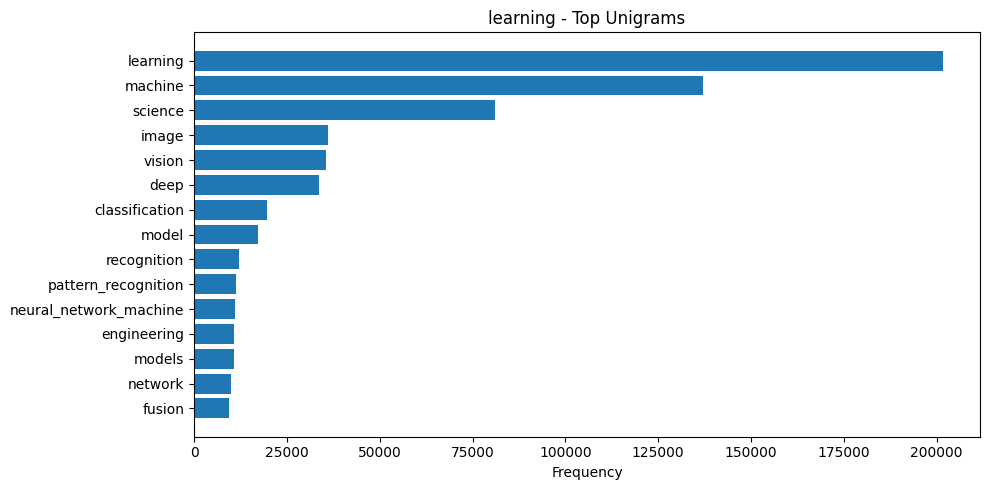

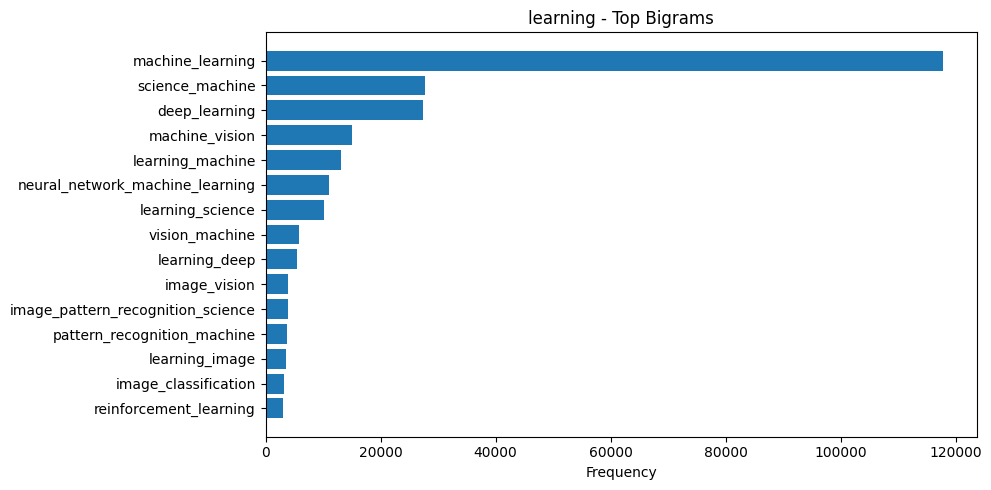

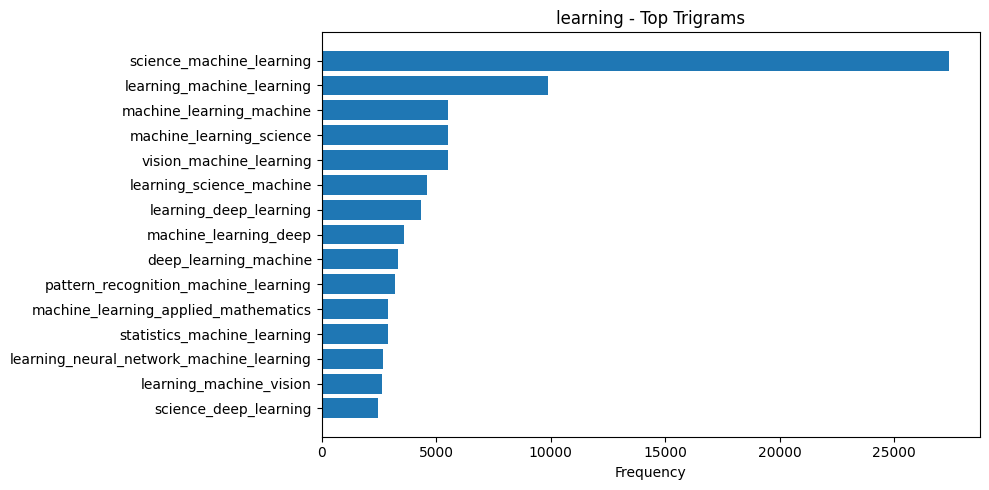

In [2]:
visualize_dataset(r"data\learning_dataset.pkl", name="learning")

## Train DMR Models

In [2]:
from fn.pipeline import train_dmr_model
train_dmr_model(
    r"data\translation_dataset.pkl",
    r"models\trans_dmr.bin",
    r"mt_mapping.pkl",
    k_topics=25,
    iterations=1900,
    log_filename="mt_log.txt"    
)


Training DMR model...


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tomotopy\models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


Iter 10: LL per word = -8.317972
Iter 20: LL per word = -7.896166
Iter 30: LL per word = -7.702061
Iter 40: LL per word = -7.595943
Iter 50: LL per word = -7.523208
Iter 60: LL per word = -7.474788
Iter 70: LL per word = -7.437647
Iter 80: LL per word = -7.410685
Iter 90: LL per word = -7.390491
Iter 100: LL per word = -7.374456
Iter 110: LL per word = -7.359653
Iter 120: LL per word = -7.352352
Iter 130: LL per word = -7.341603
Iter 140: LL per word = -7.331920
Iter 150: LL per word = -7.323304
Iter 160: LL per word = -7.319702
Iter 170: LL per word = -7.314898
Iter 180: LL per word = -7.310353
Iter 190: LL per word = -7.305036
Iter 200: LL per word = -7.304310
Iter 210: LL per word = -7.295541
Iter 220: LL per word = -7.292119
Iter 230: LL per word = -7.292389
Iter 240: LL per word = -7.291638
Iter 250: LL per word = -7.286800
Iter 260: LL per word = -7.283838
Iter 270: LL per word = -7.277676
Iter 280: LL per word = -7.274963
Iter 290: LL per word = -7.274500
Iter 300: LL per word =

(<tomotopy.models.DMRModel at 0x22bd991ceb0>,
 {'https://openalex.org/W3165773438': [0.0036313545424491167,
   0.0050900038331747055,
   0.002449881285429001,
   0.402010440826416,
   0.004070419818162918,
   0.0011866538552567363,
   0.23087480664253235,
   0.0017955716466531157,
   0.006444326601922512,
   0.0022877079900354147,
   0.0050936429761350155,
   0.0005882548866793513,
   0.0040945373475551605,
   0.039228036999702454,
   0.0030796267092227936,
   0.003713163547217846,
   0.004139964934438467,
   0.002075162250548601,
   0.002766494872048497,
   0.0010644749272614717,
   0.002430587774142623,
   0.0022454119753092527,
   0.03655537962913513,
   0.0047364505007863045,
   0.22834764420986176],
  'https://openalex.org/W2904259649': [0.0015265099937096238,
   0.0025964248925447464,
   0.0005365082761272788,
   0.632274866104126,
   0.0009557329467497766,
   0.003907283768057823,
   0.00252912868745625,
   0.00031530612614005804,
   0.00022944969532545656,
   0.0021106165368109

In [4]:
train_dmr_model(
    r"data\learning_dataset.pkl",
    r"models\learning_dmr.bin",
    r"ml_mapping.pkl",
    k_topics=30,
    iterations=5000,
    log_filename = "ml_log.txt"
)

Training DMR model...
Iter 10: LL per word = -9.162822
Iter 20: LL per word = -8.539621
Iter 30: LL per word = -8.272783
Iter 40: LL per word = -8.133392
Iter 50: LL per word = -8.048740
Iter 60: LL per word = -7.993579
Iter 70: LL per word = -7.954998
Iter 80: LL per word = -7.925898
Iter 90: LL per word = -7.905782
Iter 100: LL per word = -7.887726
Iter 110: LL per word = -7.873554
Iter 120: LL per word = -7.863402
Iter 130: LL per word = -7.853656
Iter 140: LL per word = -7.847463
Iter 150: LL per word = -7.840525
Iter 160: LL per word = -7.835519
Iter 170: LL per word = -7.830849
Iter 180: LL per word = -7.826186
Iter 190: LL per word = -7.823561
Iter 200: LL per word = -7.820517
Iter 210: LL per word = -7.817188
Iter 220: LL per word = -7.815712
Iter 230: LL per word = -7.812291
Iter 240: LL per word = -7.810736
Iter 250: LL per word = -7.808276
Iter 260: LL per word = -7.806768
Iter 270: LL per word = -7.803738
Iter 280: LL per word = -7.804264
Iter 290: LL per word = -7.801615
I

(<tomotopy.models.DMRModel at 0x22bd9da1070>,
 {'https://openalex.org/W4214671012': [0.0030156061984598637,
   0.0029254653491079807,
   0.3802875280380249,
   0.0041098035871982574,
   0.0003473443794064224,
   0.001182585721835494,
   0.001300983363762498,
   0.2104288935661316,
   0.0021614800207316875,
   0.02175782434642315,
   0.005118193570524454,
   0.05773899704217911,
   0.058865826576948166,
   0.002180535579100251,
   0.0009839616250246763,
   0.0005926698795519769,
   0.0008341055945493281,
   0.006908378563821316,
   0.01158360205590725,
   0.0008802791126072407,
   0.0005680075264535844,
   0.003069868078455329,
   0.00274656992405653,
   0.0012230108259245753,
   0.003382486989721656,
   0.000564805930480361,
   0.0005564117454923689,
   0.0007481797365471721,
   0.00512275192886591,
   0.2088138312101364],
  'https://openalex.org/W3214861772': [0.0014717101585119963,
   0.08616907149553299,
   0.0007914244197309017,
   0.0005151606164872646,
   0.009044129401445389,
  

## Elbow Method Visualization

Running lambda = 0.00
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.05
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.10
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.15
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.20
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.25
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.30
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.35
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.40
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.45
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.50
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.55
Extracting topic distributions...
Running segmentation DP...
Runn

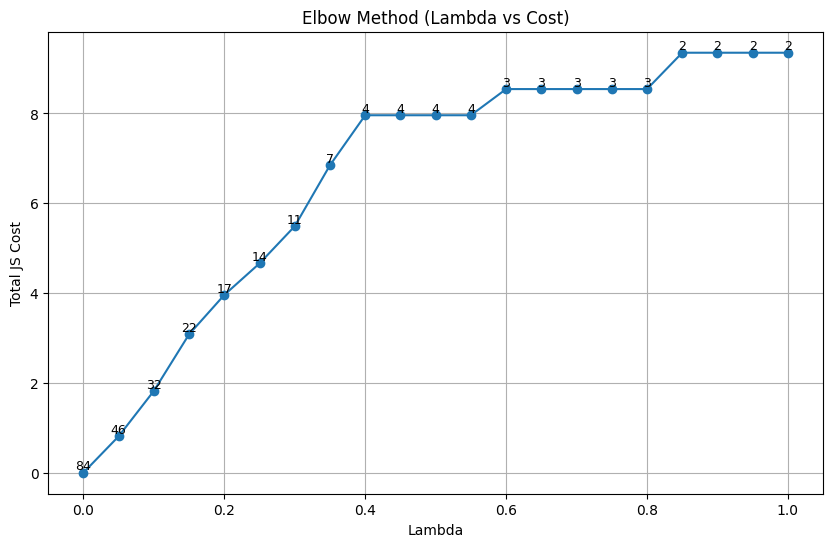

In [5]:
from fn.utils import sweep_lambda, plot_elbow
dataset_path = r"data\translation_dataset.pkl"
model_path = r"models\trans_dmr.bin"

lambdas, costs, segments = sweep_lambda(dataset_path, model_path)

plot_elbow(lambdas, costs, segments)

Running lambda = 0.00
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.05
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.10
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.15
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.20
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.25
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.30
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.35
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.40
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.45
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.50
Extracting topic distributions...
Running segmentation DP...
Running lambda = 0.55
Extracting topic distributions...
Running segmentation DP...
Runn

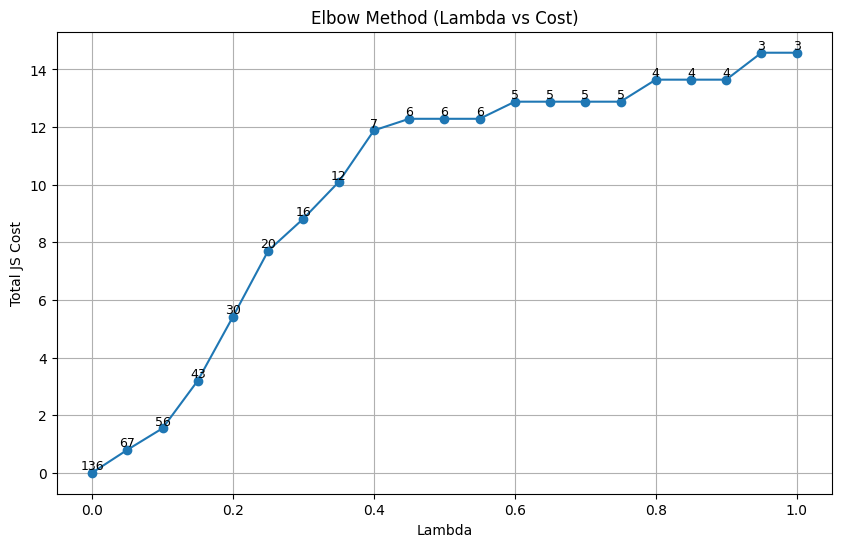

In [6]:
from fn.utils import sweep_lambda, plot_elbow
dataset_path = r"data\learning_dataset.pkl"
model_path = r"models\learning_dmr.bin"
lambdas, costs, segments = sweep_lambda(dataset_path, model_path)

plot_elbow(lambdas, costs, segments)


In [7]:
import tomotopy as tp


def print_dmr_topics(model, top_n=10):
    for topic_id in range(model.k):
        words = model.get_topic_words(topic_id, top_n=top_n)

        topic_str = ", ".join([
            f"{w}:{p:.3f}"   
            for w, p in words
        ])

        print(f"Topic {topic_id:02d}: {topic_str}")


model = tp.DMRModel.load("models/trans_dmr.bin")

print_dmr_topics(model, top_n=10)

Topic 00: language:0.076, corpus:0.054, linguistics:0.041, mining:0.034, machine:0.034, natural:0.031, science:0.031, processing:0.031, translation:0.019, extraction:0.016
Topic 01: translation:0.044, biology:0.019, machine:0.018, protein:0.016, molecular_biology:0.013, prediction:0.011, sequences:0.009, rna:0.008, bioinformatics:0.007, genetic:0.007
Topic 02: language:0.152, sign:0.044, model:0.029, models:0.021, bert:0.020, processing:0.019, pre_trained:0.018, pre_training:0.015, natural:0.014, question_answering:0.013
Topic 03: translation:0.117, machine:0.103, neural:0.088, language:0.041, nmt:0.026, model:0.026, processing:0.021, science:0.021, learning:0.018, natural:0.017
Topic 04: translation:0.030, machine:0.014, performance:0.007, set:0.006, proposed:0.006, accuracy:0.005, task:0.005, source:0.005, models:0.005, features:0.005
Topic 05: traduction:0.006, les:0.005, mso:0.004, est:0.004, une:0.004, dans:0.004, automatica:0.003, font:0.003, video_game:0.003, qui:0.003
Topic 06:

## Choose lambda and postprocess segments

### Machine Translation

In [12]:
import os
import pandas as pd

from fn.pipeline import build_timeline_from_model
from fn.utils import segments_to_dataframe 


def run_timeline_and_save():
    dataset_path = r"data\translation_dataset.pkl"
    model_path = r"models\trans_dmr.bin"

    print("Running timeline model...")

    result = build_timeline_from_model(
        dataset_path=dataset_path,
        model_path=model_path,
        lambda_penalty=0.15,
        k_topics=25
    )

    print("Converting to dataframe...")

    df = segments_to_dataframe(result)

    output_path = r"data\timeline_segments.csv"

    print("Saving to:", output_path)
    df.to_csv(output_path, index=False, encoding="utf-8")

    print("Done. Rows:", len(df))

    return df

mt_df=run_timeline_and_save()
mt_df

Running timeline model...
Extracting topic distributions...
Running segmentation DP...
Converting to dataframe...
Saving to: data\timeline_segments.csv
Done. Rows: 22


,start_year,end_year,period,num_docs,topic,topic_vector
0,1819,1852,2,2,22,"[0.001648953213589266, 0.0005294394795782864, ..."
1,1899,1899,1,1,21,"[0.002052915282547474, 0.00036862309207208455,..."
2,1933,1933,1,2,12,"[0.03986804187297821, 0.008309818804264069, 0...."
3,1941,1941,1,2,22,"[0.0006004791357554495, 0.0008872346952557564,..."
4,1942,1942,1,1,8,"[0.00046344788279384375, 0.000623038096819073,..."
5,1943,1947,2,3,12,"[0.019718032330274582, 0.010781359247630462, 0..."
6,1949,1949,1,1,4,"[0.0009913655230775476, 0.247931107878685, 0.0..."
7,1950,1950,1,1,8,"[0.006831350736320019, 0.0013033285504207015, ..."
8,1951,1951,1,3,12,"[0.017312824726104736, 0.0028142547234892845, ..."
9,1952,1952,1,1,22,"[0.09539119899272919, 0.002694470575079322, 0...."


In [13]:
import numpy as np
import pandas as pd


def merge_segments(df, min_docs=10):
    df = df[df["num_docs"] >= min_docs].copy()
    df = df.sort_values("start_year").reset_index(drop=True)

    merged_rows = []
    current = None

    for _, row in df.iterrows():
        vec = np.array(row["topic_vector"], dtype=np.float32)

        start_year = int(row["start_year"])
        end_year = int(row["end_year"])

        if current is None:
            current = {
                "start_year": start_year,
                "end_year": end_year,
                "num_docs": row["num_docs"],
                "topic": row["topic"],
                "vector_sum": vec * row["num_docs"]
            }
            continue

        if row["topic"] == current["topic"]:
            current["end_year"] = end_year
            current["num_docs"] += row["num_docs"]
            current["vector_sum"] += vec * row["num_docs"]

        else:
            bary = current["vector_sum"] / current["num_docs"]

            merged_rows.append({
                "start_year": current["start_year"],
                "end_year": current["end_year"],
                "period": current["end_year"] - current["start_year"] + 1,
                "num_docs": current["num_docs"],
                "topic": current["topic"],
                "topic_vector": bary.tolist()
            })

            current = {
                "start_year": start_year,
                "end_year": end_year,
                "num_docs": row["num_docs"],
                "topic": row["topic"],
                "vector_sum": vec * row["num_docs"]
            }

    # finalize
    if current is not None:
        bary = current["vector_sum"] / current["num_docs"]

        merged_rows.append({
            "start_year": current["start_year"],
            "end_year": current["end_year"],
            "period": current["end_year"] - current["start_year"] + 1,
            "num_docs": current["num_docs"],
            "topic": current["topic"],
            "topic_vector": bary.tolist()
        })

    return pd.DataFrame(merged_rows)

merge_segments(mt_df).to_csv(r"output\mt_df.csv", index=False)
merge_segments(mt_df)

,start_year,end_year,period,num_docs,topic,topic_vector
0,1957,1959,3,10,12,"[0.003987296484410763, 0.004586042836308479, 0..."
1,1960,1963,4,23,11,"[0.03347364068031311, 0.005454874597489834, 0...."
2,1964,1968,5,36,8,"[0.0034465817734599113, 0.024163542315363884, ..."
3,1969,1983,15,182,12,"[0.035289835184812546, 0.033305466175079346, 0..."
4,1984,2000,17,735,8,"[0.048499107360839844, 0.019363179802894592, 0..."
5,2001,2024,24,7236,4,"[0.03540864586830139, 0.007757830433547497, 0...."


In [14]:
import os
import pandas as pd

from fn.pipeline import build_timeline_from_model
from fn.utils import segments_to_dataframe  # hàm bạn vừa sửa


def run_timeline_and_save():
    dataset_path = r"data\learning_dataset.pkl"
    model_path = r"models\learning_dmr.bin"

    print("Running timeline model...")

    result = build_timeline_from_model(
        dataset_path=dataset_path,
        model_path=model_path,
        lambda_penalty=0.1,
        k_topics=25
    )

    print("Converting to dataframe...")

    df = segments_to_dataframe(result)

    output_path = r"data\timeline_segments.csv"

    print("Saving to:", output_path)
    df.to_csv(output_path, index=False, encoding="utf-8")

    print("Done. Rows:", len(df))

    return df

ml_df=run_timeline_and_save()
ml_df

Running timeline model...
Extracting topic distributions...
Running segmentation DP...
Converting to dataframe...
Saving to: data\timeline_segments.csv
Done. Rows: 56


,start_year,end_year,period,num_docs,topic,topic_vector
0,1744,1744,1,1,4,"[0.012521293014287949, 0.003350968472659588, 0..."
1,1801,1801,1,1,4,"[0.0008125472231768072, 0.0003067297802772373,..."
2,1819,1819,1,1,12,"[0.16094398498535156, 0.004715822171419859, 0...."
3,1842,1842,1,1,11,"[0.08346448093652725, 0.001082998001947999, 0...."
4,1852,1852,1,1,22,"[0.0009333531488664448, 0.001057215966284275, ..."
5,1856,1856,1,1,24,"[0.00415254570543766, 0.007680029608309269, 0...."
6,1859,1859,1,1,25,"[0.0008265390642918646, 0.013826129026710987, ..."
7,1865,1865,1,2,18,"[0.09838701784610748, 0.03997746855020523, 0.0..."
8,1886,1886,1,1,24,"[0.0022042260970920324, 0.008232166059315205, ..."
9,1888,1888,1,1,0,"[0.7436022162437439, 0.0037153593730181456, 0...."


In [15]:
merge_segments(ml_df).to_csv(r"output\ml_df.csv", index=False)
merge_segments(ml_df)

,start_year,end_year,period,num_docs,topic,topic_vector
0,1927,1928,2,11,24,"[0.0785331279039383, 0.0038075572811067104, 0...."
1,1930,1932,3,21,15,"[0.04195733368396759, 0.03096574917435646, 0.0..."
2,1939,1942,4,45,11,"[0.08596032112836838, 0.008673802949488163, 0...."
3,1943,1943,1,10,9,"[0.13427025079727173, 0.006893897894769907, 0...."
4,1945,1951,7,154,11,"[0.07828274369239807, 0.011872970499098301, 0...."
5,1952,1966,15,1083,15,"[0.0897386372089386, 0.023735618218779564, 0.0..."
6,1967,2013,47,31074,25,"[0.03797069191932678, 0.019570214673876762, 0...."
7,2014,2024,11,10282,21,"[0.005130319856107235, 0.00979367271065712, 0...."


# Make Details

In [3]:
from fn.make_details import make_details

questions_map = {
    "main research themes topics approaches": "What are the main research themes and approaches discussed in these papers?",
    "models methods contributions key results": "List the specific models and their key contributions as described in the context.",
}

make_details(
    r"output\mt_df.csv",
    r"data\machine_translation_docs_info.json",
    r"models\trans_dmr.bin",
    r"output\mt.json",
    r"models\mt_mapping.pkl",
    questions_map
)

Saved to output\mt.json


In [7]:
from fn.make_details import make_details

questions_map = {
    "main research themes topics approaches": "What are the main research themes and approaches discussed in these papers?",
    "models methods contributions key results": "List the specific models and their key contributions as described in the context.",
}

make_details(
    r"output\ml_df.csv",
    r"data\machine_learning_docs_info.json",
    r"models\learning_dmr.bin",
    r"output\ml.json",
    r"models\ml_mapping.pkl",
    questions_map
)

Saved to output\ml.json
